# FitzHugh-Nagumo Bayesian Operator Inference

This notebook demonstrates Bayesian operator inference for the FitzHugh-Nagumo system using:
1. POD for dimensionality reduction
2. Gaussian Process regression for learning dynamics
3. SVI (Stochastic Variational Inference) for operator learning with stability constraints

## 1. Configuration & Imports

### Configuration Notes

**Data Scaling Strategy:**
- `USE_SCALED_DATA=True`: GPs fit on standardized data (mean=0, std=1), improving numerical conditioning
- `USE_SCALED_DATA=False`: GPs fit on original data directly

**How it works:**
1. GPs learn in scaled/unscaled space based on flag
2. Operator dynamics ALWAYS computed in original space (ROM requirement)
3. When scaled: sample X in scaled space → transform to original → compute f(X) → scale derivative back
4. This maintains mathematical consistency: d(scaled_x)/dt = d(original_x)/dt / std

**Reproducibility:**
- `RANDOM_SEED=42`: Controls all random number generation for fair comparison with baseline method
- Ensures reproducible results across: data noise, time sampling, GP hyperparameter sampling, and SVI

In [ ]:
# Setup paths and imports FIRST (before any random operations)
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), '..'))

import numpy as np
import random
import jax
import jax.numpy as jnp
from jax.scipy.special import gammaln

import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.spatial.distance import cdist

import opinf
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam

# Import from core and local config
from core import (
    summarize_experiment,
    generate_trajectory,
    BayesianGP,
    RBFKernel,
    get_c_phi,
    DataScaler,
)
import config

# ============================================================================
# SET RANDOM SEEDS IMMEDIATELY AFTER IMPORTS - BEFORE ANY CONFIGURATION
# This ensures identical data generation with 01_gpbayes_opinf.ipynb
# ============================================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
rng_key = jax.random.PRNGKey(RANDOM_SEED)

# Configuration parameters (set AFTER seeds so no random state is consumed)
USE_SCALED_DATA = True  # Use scaled data for GP fitting and inference
normalization = 1e-5

training_span = (0, 6)
num_samples = 800
noiselevel = 0.01
num_regression_points = num_samples * 1
numPODmodes = 3
num_pulls = 200

# Setup time domains
config.time_domain = np.linspace(0, 8, 801)
time_domain_test = np.linspace(0, training_span[-1], num_regression_points)
time_domain_eval_training = np.linspace(0, training_span[-1], num_regression_points)

if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

## 2. Helper Functions & Classes

In [25]:
# JAX helper functions for operator construction
def binom(x, y):
    return jnp.exp(gammaln(x + 1) - gammaln(y + 1) - gammaln(x - y + 1))

def Quadraticckron(state):
    return jnp.concatenate(
        [state[i] * state[: i + 1] for i in range(state.shape[0])],
        axis=0,
    )

def khatri_rao(a, b):
    return jnp.vstack([jnp.kron(a[:, k], b[:, k]) for k in range(b.shape[1])]).T

class JaxCompatibleModel(opinf.models.ContinuousModel):
    """OpInf model with JAX-compatible data matrix assembly."""
    
    def _assemble_data_matrix(self, states, inputs):
        blocks = []
        for i in self._indices_of_operators_to_infer:
            op = self.operators[i]
            if isinstance(op, opinf.operators.ConstantOperator):
                block = jnp.ones((1, jnp.atleast_1d(states).shape[-1]))
            elif isinstance(op, opinf.operators.LinearOperator):
                block = jnp.atleast_2d(states)
            elif isinstance(op, opinf.operators.QuadraticOperator):
                block = Quadraticckron(jnp.atleast_2d(states))
            elif isinstance(op, opinf.operators.InputOperator):
                block = jnp.atleast_2d(inputs)
            elif isinstance(op, opinf.operators.StateInputOperator):
                block = khatri_rao(jnp.atleast_2d(inputs), jnp.atleast_2d(states))
            else:
                raise ValueError(f"Unknown operator type: {type(op)}")
            blocks.append(block.T)
        return jnp.hstack(blocks)

In [26]:
# GP helper functions
def flatten_time(t: jnp.ndarray) -> jnp.ndarray:
    """Return t with shape (n,) no matter the input shape."""
    return jnp.ravel(t)

def rbf_eval(lengthscale: float, variance: float, t: jnp.ndarray, t2: jnp.ndarray) -> jnp.ndarray:
    """RBF kernel matrix K_ij = variance * exp(-(t_i-t_j)^2 / (2*ell^2))."""
    t = flatten_time(t)
    t2 = flatten_time(t2)
    diff = t[:, None] - t2[None, :]
    ell2 = lengthscale ** 2
    return variance * jnp.exp(-diff**2 / (2.0 * ell2))

def joint_gp_derivatives(Ls, Vs, time1, time2, use_scaled=USE_SCALED_DATA):
    """
    Compute GP derivative mean and covariance.
    
    Parameters
    ----------
    use_scaled : bool
        If True, works in scaled space (derivatives of scaled states)
        If False, works in original space (derivatives of original states)
    """
    K_yys, K_zys, K_zzs = [], [], []
    
    for i in range(numPODmodes):
        ell2 = Ls[i]**2
        
        rbf_yy = rbf_eval(Ls[i], Vs[i], time1, time1) 
        rbf_zy = rbf_eval(Ls[i], Vs[i], time2, time1)
        rbf_zz = rbf_eval(Ls[i], Vs[i], time2, time2)
        
        K_yy = rbf_yy + 1e-5 * np.eye(len(time1))
        
        diff_zy = time2[:, None] - time1[None, :]
        K_zy = -(diff_zy / ell2) * rbf_zy
        
        diff_zz = time2[:, None] - time2[None, :]
        K_zz = ((1 - (diff_zz**2 / ell2)) / ell2) * rbf_zz
        
        K_yys.append(K_yy)
        K_zys.append(K_zy)
        K_zzs.append(K_zz)

    snapshots_for_gp = snapshots_compressed_scaled if use_scaled else snapshots_compressed
    
    mu_z, cov_z = [], []
    for i in range(numPODmodes):
        w = jnp.linalg.solve(K_yys[i], snapshots_for_gp[i])
        mu_zi = K_zys[i] @ w
        mu_z.append(mu_zi)

        cov_zi = K_zzs[i] - K_zys[i] @ jnp.linalg.solve(K_yys[i], K_zys[i].T)
        cov_z.append(cov_zi)

    return jnp.array(mu_z), jnp.array(cov_z)

In [27]:
# Simple GPR implementation
class SimpleGPR:
    """Simple Gaussian Process Regression with RBF kernel."""
    
    def __init__(self, length_scale_init=1.0, variance_init=1.0, noise_init=0.01):
        self.length_scale = length_scale_init
        self.variance = variance_init
        self.noise = noise_init
        self.X_train = None
        self.y_train = None
        self.K_inv = None
        
    def rbf_kernel(self, X1, X2, length_scale, variance):
        dists = cdist(X1, X2, 'sqeuclidean')
        return variance * np.exp(-dists / (2 * length_scale**2))
    
    def neg_log_marginal_likelihood(self, params):
        length_scale, variance, noise = np.exp(params)
        
        K = self.rbf_kernel(self.X_train, self.X_train, length_scale, variance)
        K_noise = K + (noise + 1e-8) * np.eye(len(self.X_train))
        
        try:
            L = np.linalg.cholesky(K_noise)
            alpha = np.linalg.solve(L.T, np.linalg.solve(L, self.y_train))
            log_likelihood = (-0.5 * self.y_train.T @ alpha 
                            - np.sum(np.log(np.diag(L))) 
                            - 0.5 * len(self.X_train) * np.log(2 * np.pi))
            return -log_likelihood
        except np.linalg.LinAlgError:
            return 1e10
    
    def fit(self, X, y, verbose=True):
        self.X_train = X
        self.y_train = y
        
        init_params = np.log([self.length_scale, self.variance, self.noise])
        result = minimize(self.neg_log_marginal_likelihood, init_params,
                         method='L-BFGS-B', options={'maxiter': 100})
        
        self.length_scale, self.variance, self.noise = np.exp(result.x)
        
        if verbose:
            print(f"  Length scale: {self.length_scale:.6f}")
            print(f"  Variance: {self.variance:.6f}")
            print(f"  Noise: {self.noise:.6f}")
        
        K = self.rbf_kernel(self.X_train, self.X_train, self.length_scale, self.variance)
        K_noise = K + (self.noise + 1e-8) * np.eye(len(self.X_train))
        self.K_inv = np.linalg.inv(K_noise)
        
        return self
    
    def predict(self, X_test, return_std=True):
        K_star = self.rbf_kernel(self.X_train, X_test, self.length_scale, self.variance)
        mean = K_star.T @ self.K_inv @ self.y_train
        
        if return_std:
            K_star_star = self.rbf_kernel(X_test, X_test, self.length_scale, self.variance)
            cov = K_star_star - K_star.T @ self.K_inv @ K_star
            std = np.sqrt(np.diag(cov) + self.noise)
            return mean, std
        
        return mean

In [28]:
# Derivative matching visualization
def plot_derivative_matching(rom, operator, Ls, Vs, time_domain_sampled, time_domain_eval,
                            snapshots_compressed, num_modes, input_func, data_scaler, 
                            use_scaled, title="Operator Derivative Matching"):
    """
    Plot comparison between GP-predicted derivatives and operator-predicted derivatives.
    
    This helps verify that the operator is producing derivatives consistent with the GP.
    """
    from scipy.interpolate import interp1d
    
    # Compute GP derivatives
    K_yys, K_zys = [], []
    for i in range(num_modes):
        ell2 = Ls[i]**2
        
        rbf_yy = rbf_eval(Ls[i], Vs[i], time_domain_sampled, time_domain_sampled)
        rbf_zy = rbf_eval(Ls[i], Vs[i], time_domain_eval, time_domain_sampled)
        
        K_yy = rbf_yy + 1e-5 * np.eye(len(time_domain_sampled))
        
        diff_zy = time_domain_eval[:, None] - time_domain_sampled[None, :]
        K_zy = -(diff_zy / ell2) * rbf_zy
        
        K_yys.append(K_yy)
        K_zys.append(K_zy)
    
    # Select appropriate data
    snapshots_for_gp = data_scaler.transform(snapshots_compressed) if use_scaled else snapshots_compressed
    
    # Compute GP derivative predictions
    mu_z_gp = []
    for i in range(num_modes):
        w = np.linalg.solve(K_yys[i], snapshots_for_gp[i])
        mu_zi = K_zys[i] @ w
        mu_z_gp.append(mu_zi)
    
    # Compute operator derivatives
    # Interpolate snapshots to eval points
    X_eval = np.zeros((num_modes, len(time_domain_eval)))
    for i in range(num_modes):
        if use_scaled:
            interp_func = interp1d(time_domain_sampled, snapshots_for_gp[i], 
                                  kind='cubic', fill_value='extrapolate')
        else:
            interp_func = interp1d(time_domain_sampled, snapshots_compressed[i], 
                                  kind='cubic', fill_value='extrapolate')
        X_eval[i] = interp_func(time_domain_eval)
    
    # Transform to original space for operator application if needed
    if use_scaled:
        X_eval_orig = data_scaler.inverse_transform(X_eval)
    else:
        X_eval_orig = X_eval
    
    # Get inputs at eval points
    inputs_eval = input_func(time_domain_eval)
    
    # Compute operator derivatives in original space
    operator_np = np.array(operator) if not isinstance(operator, np.ndarray) else operator
    rom.model._extract_operators(operator_np)
    f_X_operator = rom.model._assemble_data_matrix(X_eval_orig, inputs=inputs_eval) @ operator_np.T
    
    # Scale back if needed
    if use_scaled:
        f_X_scaled = np.array([
            f_X_operator.T[i] / data_scaler.stds_[i, 0] 
            for i in range(num_modes)
        ])
    else:
        f_X_scaled = f_X_operator.T
    
    # Create plot
    fig, axes = plt.subplots(num_modes, 1, figsize=(12, 3*num_modes))
    if num_modes == 1:
        axes = [axes]
    
    for i in range(num_modes):
        axes[i].plot(time_domain_eval, mu_z_gp[i], 'b-', linewidth=2, 
                    label='GP Derivative', alpha=0.7)
        axes[i].plot(time_domain_eval, f_X_scaled[i], 'r--', linewidth=2, 
                    label='Operator Derivative', alpha=0.7)
        
        # Compute relative error
        diff = mu_z_gp[i] - f_X_scaled[i]
        rel_error = np.linalg.norm(diff) / (np.linalg.norm(mu_z_gp[i]) + 1e-10)
        
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel(f'Mode {i} Derivative')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        axes[i].set_title(f'Mode {i} - Relative Error: {rel_error:.4f}')
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 3. Generate Data & Dimensionality Reduction

In [ ]:
# Report experimental setup
summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=1e-4,
    ndraws=num_pulls,
)

# Generate trajectory data (using same function as 01_gpbayes_opinf.ipynb)
(model, time_domain, true_states, time_domain_sampled, snapshots_sampled) = \
    generate_trajectory(config, training_span, num_samples, noiselevel)

time_domain_eval_prediction = np.linspace(0, time_domain[-1], 
                                         int(num_regression_points/training_span[-1]*time_domain[-1]))

print(f"Data shapes:")
print(f"  time_domain: {time_domain.shape}")
print(f"  true_states: {true_states.shape}")
print(f"  time_domain_sampled: {time_domain_sampled.shape}")
print(f"  snapshots_sampled: {snapshots_sampled.shape}")


EXPERIMENTAL SCENARIO
Data: 800 uniformly sampled snapshots over 0.00 ≤ t < 6.00 with 1.00% noise
Dimension: retaining 3 POD modes
Training: using 800 regression points
GP regularization: eta = 1.00e-04
Posterior: 100 draws

generating training data...done in 0.51 s.
Data shapes:
  time_domain: (801,)
  true_states: (1024, 801)
  time_domain_sampled: (800,)
  snapshots_sampled: (1024, 800)
done in 0.51 s.
Data shapes:
  time_domain: (801,)
  true_states: (1024, 801)
  time_domain_sampled: (800,)
  snapshots_sampled: (1024, 800)


In [30]:
# POD dimensionality reduction
with opinf.utils.TimedBlock(f"reducing noisy training states to {numPODmodes} dimensions"):
    basis = config.Basis(num_vectors=numPODmodes)
    basis.fit(snapshots_sampled)
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    
print(f"Reduced states shape: {snapshots_compressed.shape}")

reducing noisy training states to 3 dimensions...(512, 800) (512, 800)
(512, 800) (512, 800)
done in 0.32 s.
Reduced states shape: (3, 800)
done in 0.32 s.
Reduced states shape: (3, 800)


## 4. Data Scaling

In [31]:
# Create and fit data scaler
data_scaler = DataScaler(num_modes=numPODmodes)
data_scaler.fit(snapshots_compressed)

snapshots_compressed_scaled = data_scaler.transform(snapshots_compressed)
full_states_compressed_scaled = data_scaler.transform(full_states_compressed)

print(f"Scaler fitted:")
print(f"  Means: {data_scaler.means_.ravel()}")
print(f"  Stds: {data_scaler.stds_.ravel()}")
print(f"\nOriginal data range: [{snapshots_compressed.min():.3f}, {snapshots_compressed.max():.3f}]")
print(f"Scaled data range: [{snapshots_compressed_scaled.min():.3f}, {snapshots_compressed_scaled.max():.3f}]")
print(f"Scaled data mean per mode: {snapshots_compressed_scaled.mean(axis=1)}")
print(f"Scaled data std per mode: {snapshots_compressed_scaled.std(axis=1)}")

# Verify scaling reversibility
test_data = snapshots_compressed[:, :5]
scaled = data_scaler.transform(test_data)
unscaled = data_scaler.inverse_transform(scaled)
print(f"\nScaling reversibility test:")
print(f"  Max error: {np.abs(test_data - unscaled).max():.2e}")
print(f"  ✅ Scaling verified!")

Scaler fitted:
  Means: [11.19078874  0.50564972 -0.9500548 ]
  Stds: [11.77180192  1.87913122  1.57922867]

Original data range: [-3.859, 31.835]
Scaled data range: [-1.842, 3.195]
Scaled data mean per mode: [-1.06581410e-16 -8.88178420e-18 -7.10542736e-17]
Scaled data std per mode: [1. 1. 1.]

Scaling reversibility test:
  Max error: 9.54e-07
  ✅ Scaling verified!


## 5. Fit Prior Operator

Finding optimal prior operator via line search...
Testing 10 regularization values...
(512, 800) (512, 800)
  reg=1.0e-08: STABLE, error=1.799977
(512, 800) (512, 800)
  reg=1.0e-08: STABLE, error=1.799977
(512, 800) (512, 800)
  reg=1.0e-07: STABLE, error=1.799977
(512, 800) (512, 800)
  reg=1.0e-07: STABLE, error=1.799977
(512, 800) (512, 800)
  reg=1.0e-06: STABLE, error=1.799977
(512, 800) (512, 800)
  reg=1.0e-06: STABLE, error=1.799977
(512, 800) (512, 800)
  reg=1.0e-05: STABLE, error=1.799977
(512, 800) (512, 800)
  reg=1.0e-05: STABLE, error=1.799977
(512, 800) (512, 800)
  reg=1.0e-04: STABLE, error=1.799977
(512, 800) (512, 800)
  reg=1.0e-04: STABLE, error=1.799977
(512, 800) (512, 800)
  reg=1.0e-03: STABLE, error=1.799972
(512, 800) (512, 800)
  reg=1.0e-03: STABLE, error=1.799972
(512, 800) (512, 800)
  reg=1.0e-02: STABLE, error=1.800289
(512, 800) (512, 800)
  reg=1.0e-02: STABLE, error=1.800289
(512, 800) (512, 800)
  reg=1.0e-01: UNSTABLE (terminated at 111/800 steps

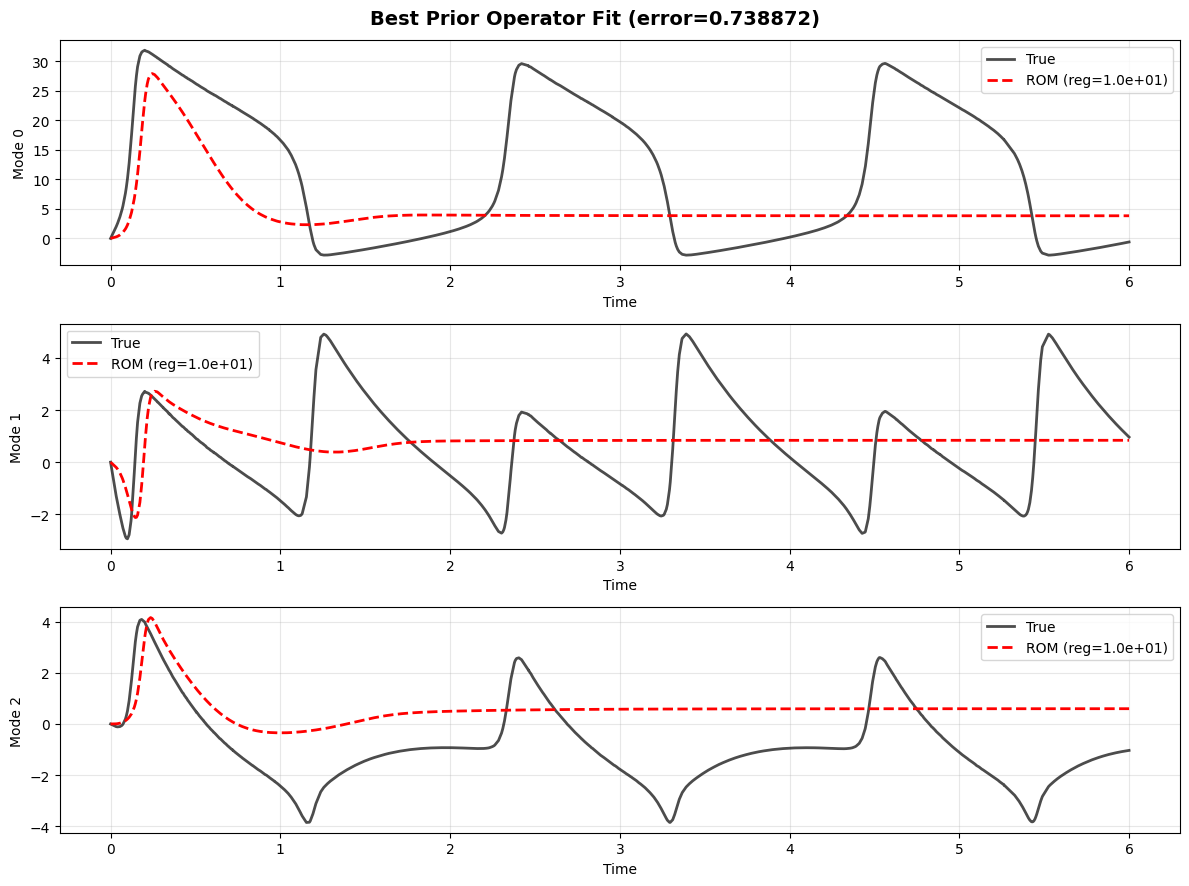

In [32]:
# Setup input function
input_func = config.ReducedOrderModel.input_func
inputs = input_func(time_domain_sampled) 
inputs_eval_time = input_func(time_domain_eval_training)

# ========================================================================
# Line Search for Best Prior Operator
# ========================================================================
print("Finding optimal prior operator via line search...")

# Test different regularization values
reg_values = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1]
best_reg = None
best_error = float('inf')
best_operator = None
best_rom = None
stable_results = []

print(f"Testing {len(reg_values)} regularization values...")

for reg in reg_values:
    try:
        # Create ROM with current regularization
        rom_candidate = opinf.ROM(
            basis=basis,
            ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_domain_sampled),
            model=JaxCompatibleModel(
                operators="cAHBN",
                solver=opinf.lstsq.L2Solver(regularizer=reg),
            )
        )
        
        # Fit the ROM
        rom_candidate.fit(states=snapshots_sampled, inputs=inputs)
        candidate_operator = rom_candidate.model.operator_matrix
        
        # Extract and set operator
        rom_candidate.model._extract_operators(np.array(candidate_operator))
        
        # Test stability on training domain
        deter_pred = rom_candidate.model.predict(
            state0=snapshots_compressed[:, 0], 
            t=time_domain_sampled, 
            input_func=input_func
        )
        deter_sol = rom_candidate.model.predict_result_
        
        # Check if stable (completed all timesteps)
        if deter_sol.t.shape[0] == snapshots_sampled.shape[1]:
            # Compute fit error
            error = np.linalg.norm(deter_pred - snapshots_compressed) / np.linalg.norm(snapshots_compressed)
            stable_results.append((reg, error, candidate_operator, rom_candidate))
            
            print(f"  reg={reg:.1e}: STABLE, error={error:.6f}")
            
            if error < best_error:
                best_error = error
                best_reg = reg
                best_operator = candidate_operator
                best_rom = rom_candidate
        else:
            print(f"  reg={reg:.1e}: UNSTABLE (terminated at {deter_sol.t.shape[0]}/{snapshots_sampled.shape[1]} steps)")
            
    except Exception as e:
        print(f"  reg={reg:.1e}: FAILED ({str(e)[:50]})")
        continue

if best_operator is None:
    raise RuntimeError("No stable operator found! Try different regularization values.")

print(f"\n✅ Best regularization: {best_reg:.1e}")
print(f"   Best fit error: {best_error:.6f}")
print(f"   Operator shape: {best_operator.shape}")

# Use best ROM
rom = best_rom
loaded_operator = best_operator

# Plot best fit
print(f"\nGenerating best fit plot...")
fig, axes = plt.subplots(numPODmodes, 1, figsize=(12, 3*numPODmodes))
if numPODmodes == 1:
    axes = [axes]

# Get best prediction
best_pred = rom.model.predict(
    state0=snapshots_compressed[:, 0],
    t=time_domain_sampled,
    input_func=input_func
)

for i in range(numPODmodes):
    axes[i].plot(time_domain_sampled, snapshots_compressed[i], 'k-', linewidth=2, label='True', alpha=0.7)
    axes[i].plot(time_domain_sampled, best_pred[i], 'r--', linewidth=2, label=f'ROM (reg={best_reg:.1e})')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel(f'Mode {i}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

fig.suptitle(f'Best Prior Operator Fit (error={best_error:.6f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Gaussian Process Regression

In [33]:
# Fit GPs for each POD mode
gp_models = []
gp_samples = {}

training_data = snapshots_compressed_scaled if USE_SCALED_DATA else snapshots_compressed
data_description = "SCALED" if USE_SCALED_DATA else "UNSCALED"

print(f"Fitting GPR models using {data_description} data...\n")

for i in range(numPODmodes):
    print(f"Mode {i}:")
    gp = SimpleGPR(
        length_scale_init=training_span[-1]/10,
        variance_init=1.0 if USE_SCALED_DATA else np.var(training_data[i]),
        noise_init=0.01
    )
    
    gp.fit(time_domain_sampled[:, None], training_data[i])
    gp_models.append(gp)
    
    gp_samples[f'lengthscale{i}'] = np.array([gp.length_scale])
    gp_samples[f'variance{i}'] = np.array([gp.variance])
    gp_samples[f'noise{i}'] = np.array([gp.noise])
    
    mean, std = gp.predict(time_domain_sampled[:, None])
    gp_samples[f'f{i}'] = mean[None, :]
    print()

print(f"✅ GPR fitting complete!")

Fitting GPR models using SCALED data...

Mode 0:
  Length scale: 0.048879
  Variance: 0.405588
  Noise: 0.000001

Mode 1:
  Length scale: 0.048879
  Variance: 0.405588
  Noise: 0.000001

Mode 1:
  Length scale: 0.041149
  Variance: 0.475094
  Noise: 0.000004

Mode 2:
  Length scale: 0.041149
  Variance: 0.475094
  Noise: 0.000004

Mode 2:
  Length scale: 0.047747
  Variance: 0.416416
  Noise: 0.000005

✅ GPR fitting complete!
  Length scale: 0.047747
  Variance: 0.416416
  Noise: 0.000005

✅ GPR fitting complete!


## 7. Visualize GP Results

Number of samples: 1


<Figure size 640x480 with 0 Axes>

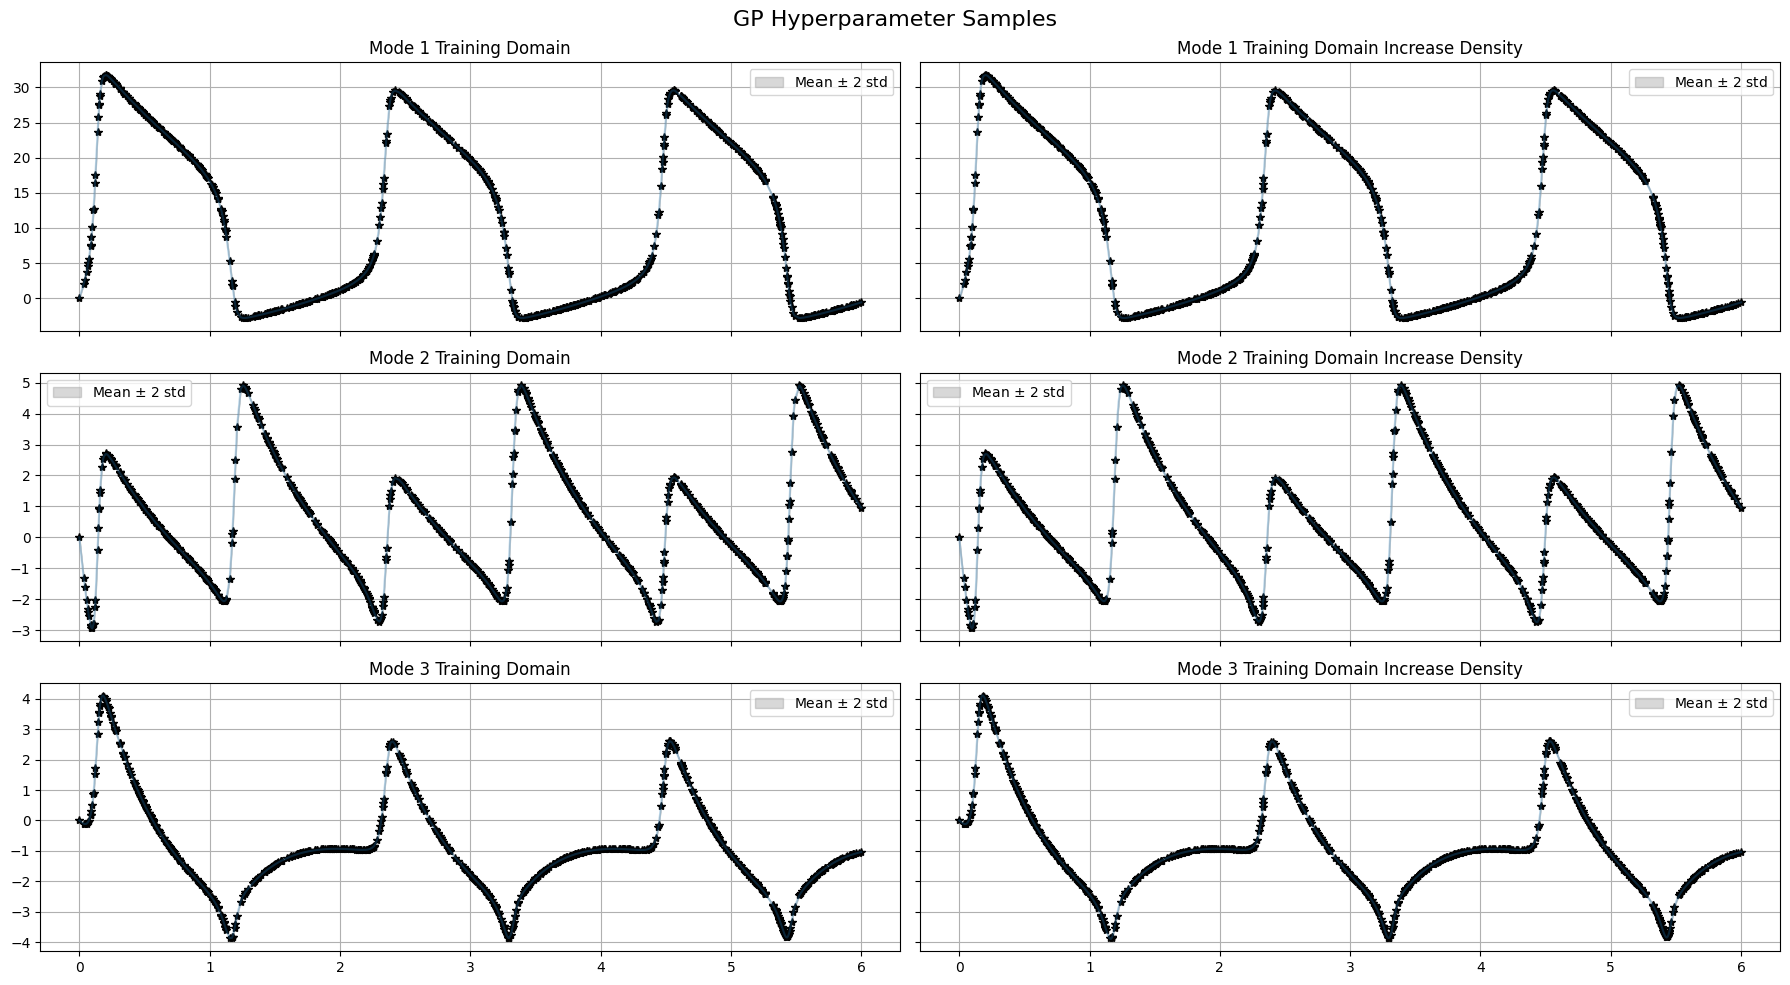

<Figure size 640x480 with 0 Axes>

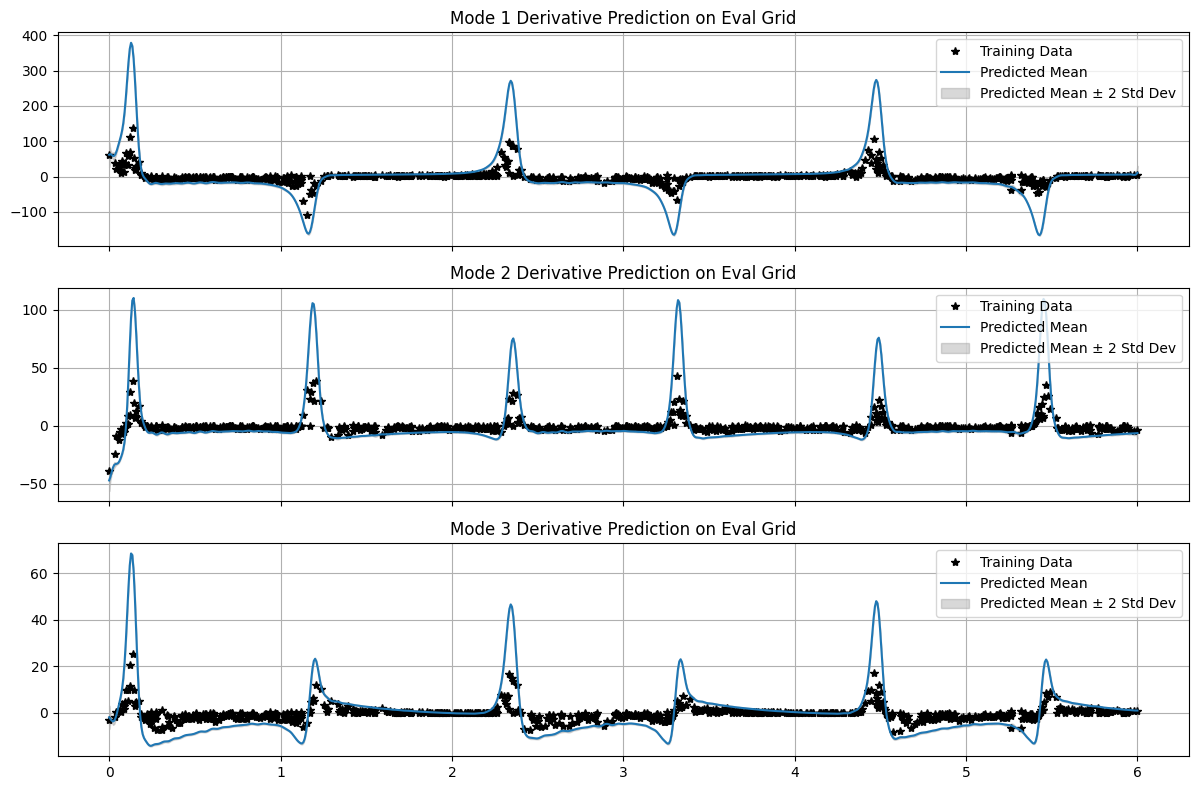

In [34]:
import fitz_plotter
import importlib
importlib.reload(fitz_plotter)

plotter = fitz_plotter.FitzPlotter(
    numPODmodes=numPODmodes,
    time_domain_training=time_domain_sampled, 
    time_domain_prediction=time_domain, 
    time_domain_eval_training=time_domain_eval_training,
    time_domain_eval_prediction=time_domain_eval_prediction,
    snapshots_training=snapshots_compressed,
    snapshots_prediction=full_states_compressed,
    scaler=data_scaler if USE_SCALED_DATA else None
)

plotter.gp_plot_state(
    lengthscales=[gp_samples[f'lengthscale{i}'] for i in range(numPODmodes)],
    variances=[gp_samples[f'variance{i}'] for i in range(numPODmodes)],
    noises=[gp_samples[f'noise{i}'] for i in range(numPODmodes)],
    max_num_samples=250,
    figsize=(18,10)
)
plt.show()

plotter.gp_plot_derivatives()
plt.show()

## 8. Compute GP Hyperparameter Statistics

In [35]:
Ls_means = np.array([gp_samples[f'lengthscale{i}'].mean() for i in range(numPODmodes)])
Vs_means = np.array([gp_samples[f'variance{i}'].mean() for i in range(numPODmodes)])
Ns_means = np.array([gp_samples[f'noise{i}'].mean() for i in range(numPODmodes)])

print("GP Hyperparameter Statistics:")
print(f"  Lengthscales: {Ls_means}")
print(f"  Variances: {Vs_means}")
print(f"  Noises: {Ns_means}")

GP Hyperparameter Statistics:
  Lengthscales: [0.04887939 0.04114942 0.0477474 ]
  Variances: [0.40558803 0.47509375 0.41641634]
  Noises: [7.95757972e-07 3.75535745e-06 4.86439783e-06]


## 8.1 Prior Operator Derivative Matching

Now that we have GP hyperparameters, visualize how well the prior operator matches GP derivatives.

Plotting prior operator derivative matching...


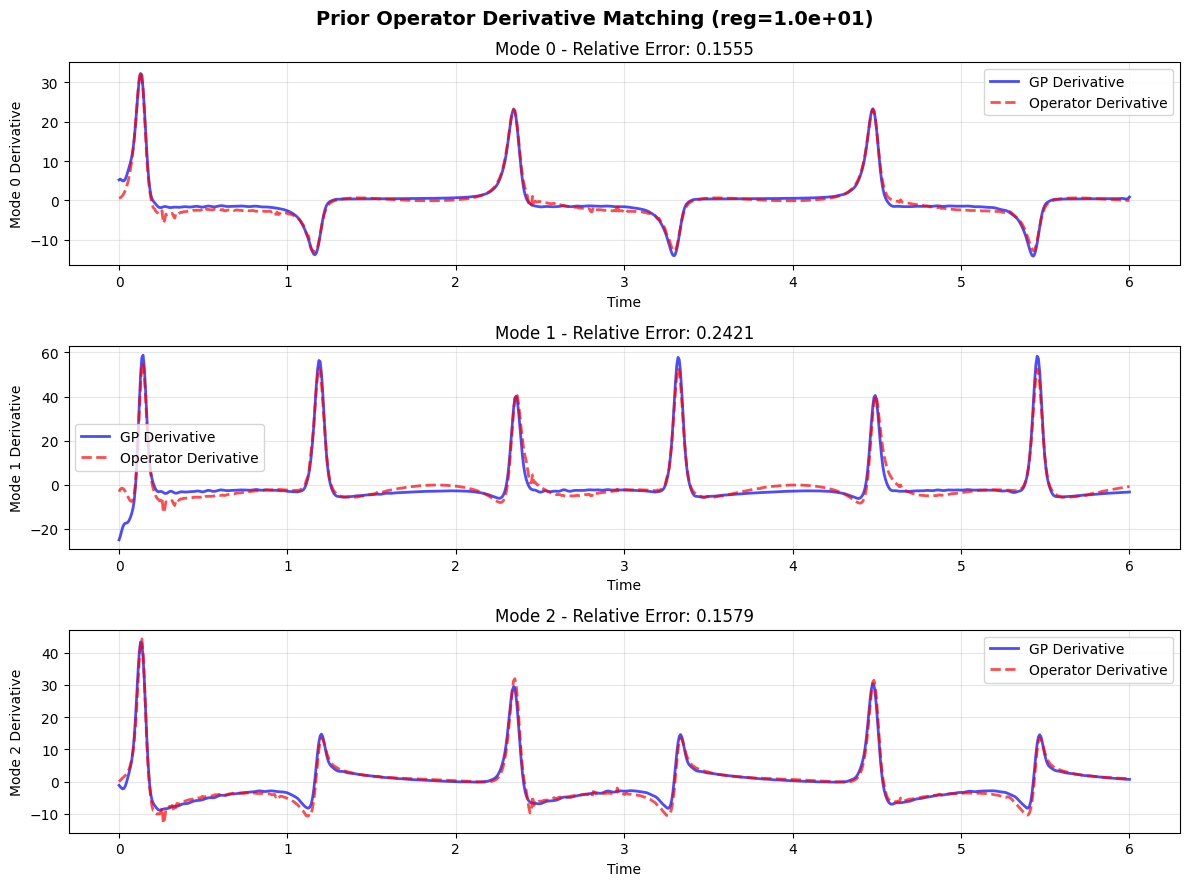

In [36]:
print("Plotting prior operator derivative matching...")
plot_derivative_matching(
    rom=rom,
    operator=loaded_operator,
    Ls=Ls_means,
    Vs=Vs_means,
    time_domain_sampled=time_domain_sampled,
    time_domain_eval=time_domain_eval_training,
    snapshots_compressed=snapshots_compressed,
    num_modes=numPODmodes,
    input_func=input_func,
    data_scaler=data_scaler,
    use_scaled=USE_SCALED_DATA,
    title=f"Prior Operator Derivative Matching (reg={best_reg:.1e})"
)


Latent state statistics computed:
  Xs_means shape: (3, 800)
  Xs_covs shape: (3, 800, 800)


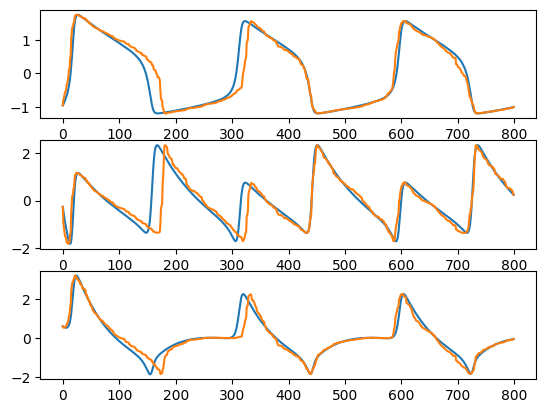

In [37]:
# Generate GP predictions for latent state statistics
eval_points = [[] for i in range(numPODmodes)] 
prediction_data = snapshots_compressed_scaled if USE_SCALED_DATA else snapshots_compressed

for i in range(numPODmodes):
    gp_samples[f'Xi{i}'] = []

for i in range(num_pulls):
    rand_idx = random.randint(0, len(gp_samples['lengthscale0'])-1)
    Ls = np.array([gp_samples[f'lengthscale{i}'][rand_idx] for i in range(numPODmodes)])
    Vs = np.array([gp_samples[f'variance{i}'][rand_idx] for i in range(numPODmodes)])
    Ns = np.array([gp_samples[f'noise{i}'][rand_idx] for i in range(numPODmodes)])

    gp = BayesianGP()
    gp.X_train = time_domain_sampled[:, None]
    for j in range(numPODmodes):
        gp.y_train = prediction_data[j]
        mean_test, std_test, _ = gp.predict_with_hypers(
            X_test=time_domain_test[:, None], 
            lengthscale=Ls[j], variance=Vs[j], noise=Ns[j]
        )
        gp_samples[f'Xi{j}'].append(mean_test)

for i in range(numPODmodes):
    gp_samples[f'Xi{i}'] = np.array(gp_samples[f'Xi{i}'])

# Compute latent state statistics
Xs_means = np.stack([gp_samples[f'Xi{i}'].mean(axis=0) for i in range(numPODmodes)], axis=0)
Xs_covs = np.stack([np.cov(gp_samples[f'Xi{i}'].T) for i in range(numPODmodes)], axis=0)

print(f"\nLatent state statistics computed:")
print(f"  Xs_means shape: {Xs_means.shape}")
print(f"  Xs_covs shape: {Xs_covs.shape}")

fig, ax = plt.subplots(numPODmodes, 1)

for i in range(numPODmodes):
    ax[i].plot(Xs_means[i])
    ax[i].plot(snapshots_compressed_scaled[i])

## 9. Bayesian Operator Inference (SVI)

In [38]:
def model(time, gamma=1e-1, gamma2=5e-2, normalization=1e-6, prior_operator = None, reparam=False, dist_type='normal',use_scaled=USE_SCALED_DATA):
    """
    Operator inference model with proper scaling support and stability enforcement.
    
    Note: gamma2 is kept for backward compatibility but not used (gamma is used for constraints)
    """
    num_time_steps = time.shape[0] 
    
    # Sample operator - Use prior operator as mean with reasonable uncertainty
    # This gives the optimizer a good starting point
    if prior_operator is not None:
        if reparam:
            operator_uncertainty = numpyro.sample(
                "O_uncert",
                dist.Normal(
                    loc=jnp.zeros_like(prior_operator),
                    scale=gamma*jnp.ones_like(prior_operator)
                )
            )
            O = numpyro.deterministic('O', prior_operator + operator_uncertainty)
        else:
            O = numpyro.sample(
                "O",
                dist.Normal(
                    loc=prior_operator,  # Start from prior operator
                    scale=gamma * jnp.ones_like(prior_operator)  # Scale with gamma for consistency
                )
            )
    else:
        raise Exception("Not Implemented yet")

    # Sample latent states
    Xs = []
    for i in range(numPODmodes):
        # Xs.append(
        #     numpyro.sample(
        #         f"X{i}",
        #         dist.MultivariateNormal(
        #             loc=Xs_means[i], 
        #             covariance_matrix=Xs_covs[i] + normalization * jnp.eye(Xs_covs[i].shape[0])
        #         ),
        #     )
        # )

        Xs.append(numpyro.deterministic(f"X{i}", Xs_means[i]))
    Xs = jnp.array(Xs)
    
    # Transform to original space if using scaled data
    if use_scaled:
        Xs_original = jnp.array([
            Xs[i] * data_scaler.stds_[i, 0] + data_scaler.means_[i, 0] 
            for i in range(numPODmodes)
        ])
    else:
        Xs_original = Xs
    
    # Compute dynamics in original space
    f_Xi_ohat = rom.model._assemble_data_matrix(Xs_original, inputs=inputs_eval_time) @ O.T
    
    # Scale derivatives if needed
    if use_scaled:
        f_Xi_scaled = jnp.array([
            f_Xi_ohat.T[i] / data_scaler.stds_[i, 0] 
            for i in range(numPODmodes)
        ])
    else:
        f_Xi_scaled = f_Xi_ohat.T

    # Get GP derivatives
    mu_z, cov_z = joint_gp_derivatives(Ls_means, Vs_means, time_domain_sampled, time, use_scaled=use_scaled)

    # ODE Contraints
    for i in range(numPODmodes):
        # mu_zi = mu_z[i]
        # cov_zi = cov_z[i]
        mu_zi = numpyro.deterministic(f"mu_z{i}", mu_z[i])
        cov_zi = numpyro.deterministic(f"cov_z{i}", cov_z[i])
        
        # FIXED: Operator output should match GP derivatives (not the other way around!)
        # We want: f(X) ~ GP_derivative, so operator output is mean, GP derivative is obs
        constraint_cov = cov_zi + gamma2 * jnp.eye(num_time_steps)
        
        numpyro.sample(
            f'ode_constraint{i}',
            dist.MultivariateNormal(f_Xi_scaled[i], constraint_cov),
            obs=mu_zi
        )

In [39]:
# Run SVI
guide = autoguide.AutoDelta(model)
optimizer = Adam(step_size=0.001)
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

normalization = 1e-4
gamma = 1e-1  # Not used anymore, kept for backward compatibility
gamma2 = 5e-2  # FIXED: Match Euler model - single gamma for both operator and constraints

print(f"Running SVI with {'SCALED' if USE_SCALED_DATA else 'UNSCALED'} data...")
print(f"  gamma (operator uncertainty & ODE constraint): {gamma}")

svi_results = svi.run(
    rng_key=rng_key, 
    num_steps=5000,
    time=time_domain_eval_training,
    normalization=normalization,
    gamma=gamma,
    gamma2=gamma2,
    prior_operator=loaded_operator,
    use_scaled=USE_SCALED_DATA
)

params = svi_results.params

# Get posterior samples - include deterministic sites for debugging
return_sites = ['O', 'X0', 'X1', 'X2']
# Add deterministic mu_z and cov_z sites for verification
for i in range(numPODmodes):
    return_sites.extend([f'mu_z{i}', f'cov_z{i}', f'ode_constraint{i}'])

predictive = Predictive(model, guide=guide, params=params, num_samples=1000, 
                       return_sites=return_sites)
predictions = predictive(
    rng_key,
    time=time_domain_eval_training, 
    normalization=normalization,
    gamma=gamma,
    gamma2=gamma2,
    prior_operator=loaded_operator,
    use_scaled=USE_SCALED_DATA
)

svi_samples = predictions
print(f"✅ SVI completed!")
print(f"   Sample keys: {list(svi_samples.keys())}")

Running SVI with SCALED data...
  gamma (operator uncertainty & ODE constraint): 0.1


100%|██████████| 5000/5000 [17:17<00:00,  4.82it/s, init loss: 201240.7656, avg. loss [4751-5000]: 28341.9629] 



✅ SVI completed!
   Sample keys: ['O', 'X0', 'X1', 'X2', 'cov_z0', 'cov_z1', 'cov_z2', 'mu_z0', 'mu_z1', 'mu_z2', 'ode_constraint0', 'ode_constraint1', 'ode_constraint2']


In [ ]:
from numpyro.infer import MCMC, NUTS, init_to_value

num_chains = 2
O_mean = svi_samples['O'].mean(axis=0)

mcmc_gamma = 1e0
mcmc_gamma2 = 1e0

nuts_kernel = NUTS(model,
                   target_accept_prob=0.9,
                   dense_mass=["O"],
                   init_strategy=init_to_value(values={"O": O_mean},),
                   max_tree_depth=12
               )
mcmc = MCMC(nuts_kernel, 
            num_chains=num_chains, 
            num_warmup=1000, 
            num_samples=500, 
          )

mcmc.run(rng_key,
         time=time_domain_eval_training, 
         normalization=normalization,
         gamma=mcmc_gamma,
         gamma2=mcmc_gamma2,
         prior_operator=O_mean,
        #  reparam=True,
         use_scaled=USE_SCALED_DATA
         )

mcmc.print_summary()

mcmc_samples = mcmc.get_samples()
mcmc_predictive = Predictive(model, mcmc_samples, return_sites=return_sites)
mcmc_predictions = mcmc_predictive(
         rng_key=rng_key,
         time=time_domain_eval_training, 
         normalization=normalization,
         gamma=mcmc_gamma,
         gamma2=mcmc_gamma2,
         prior_operator=O_mean,
        #  reparam=True,
         use_scaled=USE_SCALED_DATA
    )

sample: 100%|██████████| 1500/1500 [41:00<00:00,  1.64s/it, 127 steps of size 2.83e-02. acc. prob=0.93]  

sample: 100%|██████████| 1500/1500 [40:12<00:00,  1.61s/it, 127 steps of size 2.64e-02. acc. prob=0.94]  




                mean       std    median      5.0%     95.0%     n_eff     r_hat
    O[0,0]     11.77      0.71     11.79     10.55     12.92    973.05      1.00
    O[0,1]      1.36      0.63      1.36      0.46      2.49   1056.94      1.00
    O[0,2]     -1.42      0.73     -1.43     -2.63     -0.28   1132.07      1.00
    O[0,3]     -0.24      0.77     -0.25     -1.42      1.12    929.67      1.00
    O[0,4]      0.04      0.03      0.04     -0.01      0.08   1048.20      1.00
    O[0,5]     -5.55      0.08     -5.55     -5.69     -5.44   1070.57      1.01
    O[0,6]     -2.15      0.11     -2.15     -2.35     -1.98   1094.68      1.00
    O[0,7]      3.96      0.05      3.96      3.88      4.03    910.69      1.00
    O[0,8]      0.33      0.21      0.32     -0.00      0.67   1088.88      1.01
    O[0,9]     -9.36      0.19     -9.36     -9.68     -9.07    891.79      1.00
   O[0,10]     -6.18      0.85     -6.19     -7.59     -4.84   1120.72      1.00
   O[0,11]      0.31      0

In [41]:
final_samples = mcmc_predictions

## 9.1 Verify ODE Constraint Setup

Check that mu_z, cov_z from the model match the GP derivatives computed earlier.

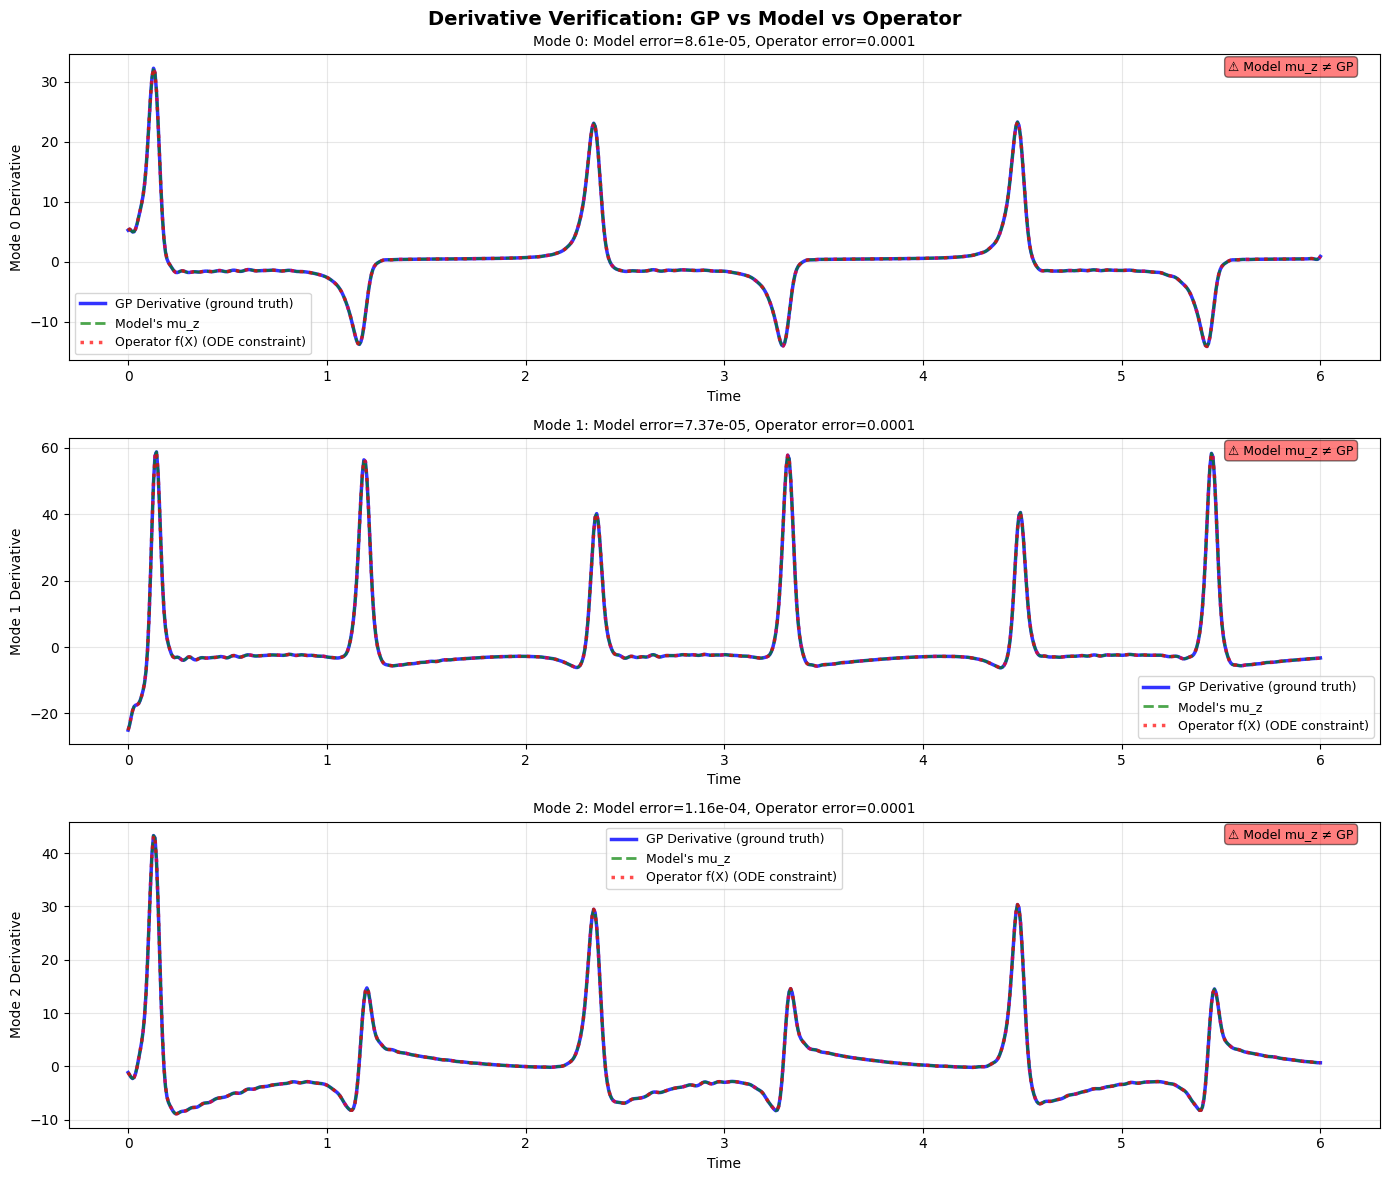

In [42]:
# Verify derivatives: GP vs Model vs Operator
# Compute GP derivatives (ground truth)
mu_z_gp, cov_z_gp = joint_gp_derivatives(
    Ls_means, Vs_means, time_domain_sampled, time_domain_eval_training, 
    use_scaled=USE_SCALED_DATA
)

# Get model's mu_z (should match GP exactly)
mean_mu_z_model = np.array([svi_samples[f'mu_z{i}'].mean(axis=0) for i in range(numPODmodes)])

# Get operator's derivatives from ode_constraint observations
mean_ode_derivatives = np.array([svi_samples[f'ode_constraint{i}'].mean(axis=0) for i in range(numPODmodes)])

# Plot comparison
fig, axes = plt.subplots(numPODmodes, 1, figsize=(14, 4*numPODmodes))
if numPODmodes == 1:
    axes = [axes]

for i in range(numPODmodes):
    ax = axes[i]
    
    # 1) GP derivatives (ground truth from earlier fitting)
    ax.plot(time_domain_eval_training, mu_z_gp[i], 'b-', 
            linewidth=2.5, label='GP Derivative (ground truth)', alpha=0.8)
    
    # 2) Model's mu_z (should match GP exactly)
    ax.plot(time_domain_eval_training, mean_mu_z_model[i], 'g--', 
            linewidth=2, label="Model's mu_z", alpha=0.7)
    
    # 3) Operator's derivatives (from ODE constraint observations)
    ax.plot(time_domain_eval_training, mean_ode_derivatives[i], 'r:', 
            linewidth=2.5, label="Operator f(X) (ODE constraint)", alpha=0.7)
    
    # Check accuracy
    model_error = np.linalg.norm(mean_mu_z_model[i] - mu_z_gp[i]) / np.linalg.norm(mu_z_gp[i])
    operator_error = np.linalg.norm(mean_ode_derivatives[i] - mu_z_gp[i]) / np.linalg.norm(mu_z_gp[i])
    
    ax.set_xlabel('Time')
    ax.set_ylabel(f'Mode {i} Derivative')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title(
        f'Mode {i}: Model error={model_error:.2e}, Operator error={operator_error:.4f}',
        fontsize=10
    )
    
    # Status indicator
    if model_error > 1e-6:
        ax.text(0.98, 0.98, '⚠️ Model mu_z ≠ GP', 
                transform=ax.transAxes, fontsize=9, ha='right',
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='red', alpha=0.5))
    else:
        ax.text(0.98, 0.98, '✓ Model mu_z = GP', 
                transform=ax.transAxes, fontsize=9, ha='right',
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

fig.suptitle('Derivative Verification: GP vs Model vs Operator', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Analyze Results

Bad solve 0, skipping
Bad solve 1, skipping
Bad solve 2, skipping
Bad solve 3, skipping
Bad solve 4, skipping
Bad solve 5, skipping
Bad solve 6, skipping
Bad solve 7, skipping
Bad solve 8, skipping
Bad solve 9, skipping
Bad solve 10, skipping
Bad solve 11, skipping
Bad solve 12, skipping
Bad solve 13, skipping
Bad solve 14, skipping
Bad solve 15, skipping
Bad solve 16, skipping
Bad solve 17, skipping
Bad solve 18, skipping
Bad solve 19, skipping
Bad solve 20, skipping
Bad solve 10, skipping
Bad solve 11, skipping
Bad solve 12, skipping
Bad solve 13, skipping
Bad solve 14, skipping
Bad solve 15, skipping
Bad solve 16, skipping
Bad solve 17, skipping
Bad solve 18, skipping
Bad solve 19, skipping
Bad solve 20, skipping
Bad solve 21, skipping
Bad solve 22, skipping
Bad solve 23, skipping
Bad solve 24, skipping
Bad solve 25, skipping
Bad solve 26, skipping
Bad solve 27, skipping
Bad solve 28, skipping
Bad solve 29, skipping
Bad solve 30, skipping
Bad solve 31, skipping
Bad solve 21, skippin

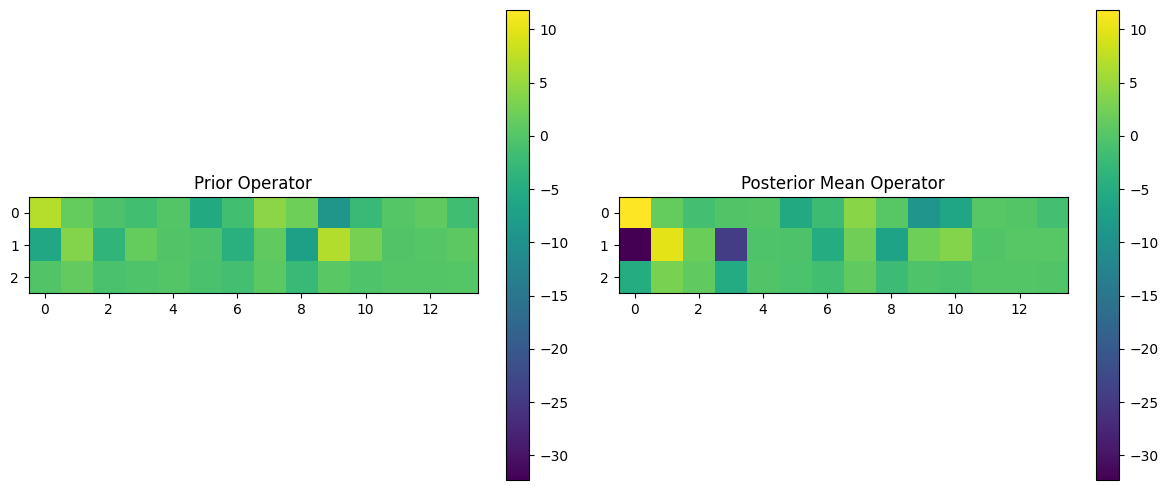

In [43]:
# Generate predictions from samples
Os = []
Xs = []
Xs_orig = []
rom_solves = []

for i in range(num_pulls):
    O = final_samples['O'][i]
    Os.append(O)
    
    X_sampled = np.array([final_samples[f'X{j}'][i] for j in range(numPODmodes)])
    Xs.append(X_sampled)
    
    if USE_SCALED_DATA:
        X_orig = data_scaler.inverse_transform(X_sampled)
    else:
        X_orig = X_sampled
    Xs_orig.append(X_orig)

    rom.model._extract_operators(np.array(O))
    rom.model.predict(state0=snapshots_compressed[:, 0], t=time_domain_eval_training, input_func=input_func)
    
    if rom.model.predict_result_.y.shape[1] < time_domain_eval_training.size:
        print(f"Bad solve {i}, skipping")
        continue
    rom_solves.append(rom.model.predict_result_.y)

Xs = np.array(Xs)
Xs_orig = np.array(Xs_orig)
Os = np.array(Os)
rom_solves = np.array(rom_solves)

print(f"\nCollected {len(rom_solves)} successful solves")
print(f"  Xs shape: {Xs.shape}")
print(f"  Os shape: {Os.shape}")

# Compute statistics
O_mean = Os.mean(axis=0)
if len(rom_solves) == 0:
    rom_solves_mean = np.zeros_like(O_mean)
    rom_solves_median = np.zeros_like(O_mean)
    rom_solves_95 = np.zeros_like(O_mean)
    rom_solves_5 = np.zeros_like(O_mean)
else:
    rom_solves_mean = rom_solves.mean(axis=0)
    rom_solves_median = np.median(rom_solves, axis=0)
    rom_solves_95 = np.percentile(rom_solves, 99, axis=0)
    rom_solves_5 = np.percentile(rom_solves, 1, axis=0)

# Visualize operators
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
vmin = min(loaded_operator.min(), O_mean.min())
vmax = max(loaded_operator.max(), O_mean.max())

im1 = ax1.imshow(loaded_operator, vmin=vmin, vmax=vmax)
ax1.set_title("Prior Operator")
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(O_mean, vmin=vmin, vmax=vmax)
ax2.set_title("Posterior Mean Operator")
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

## 10.1 Check Latent State Overfitting

Compare posterior X samples with GP predictions and actual snapshots to check for overfitting.

Checking for latent state overfitting...



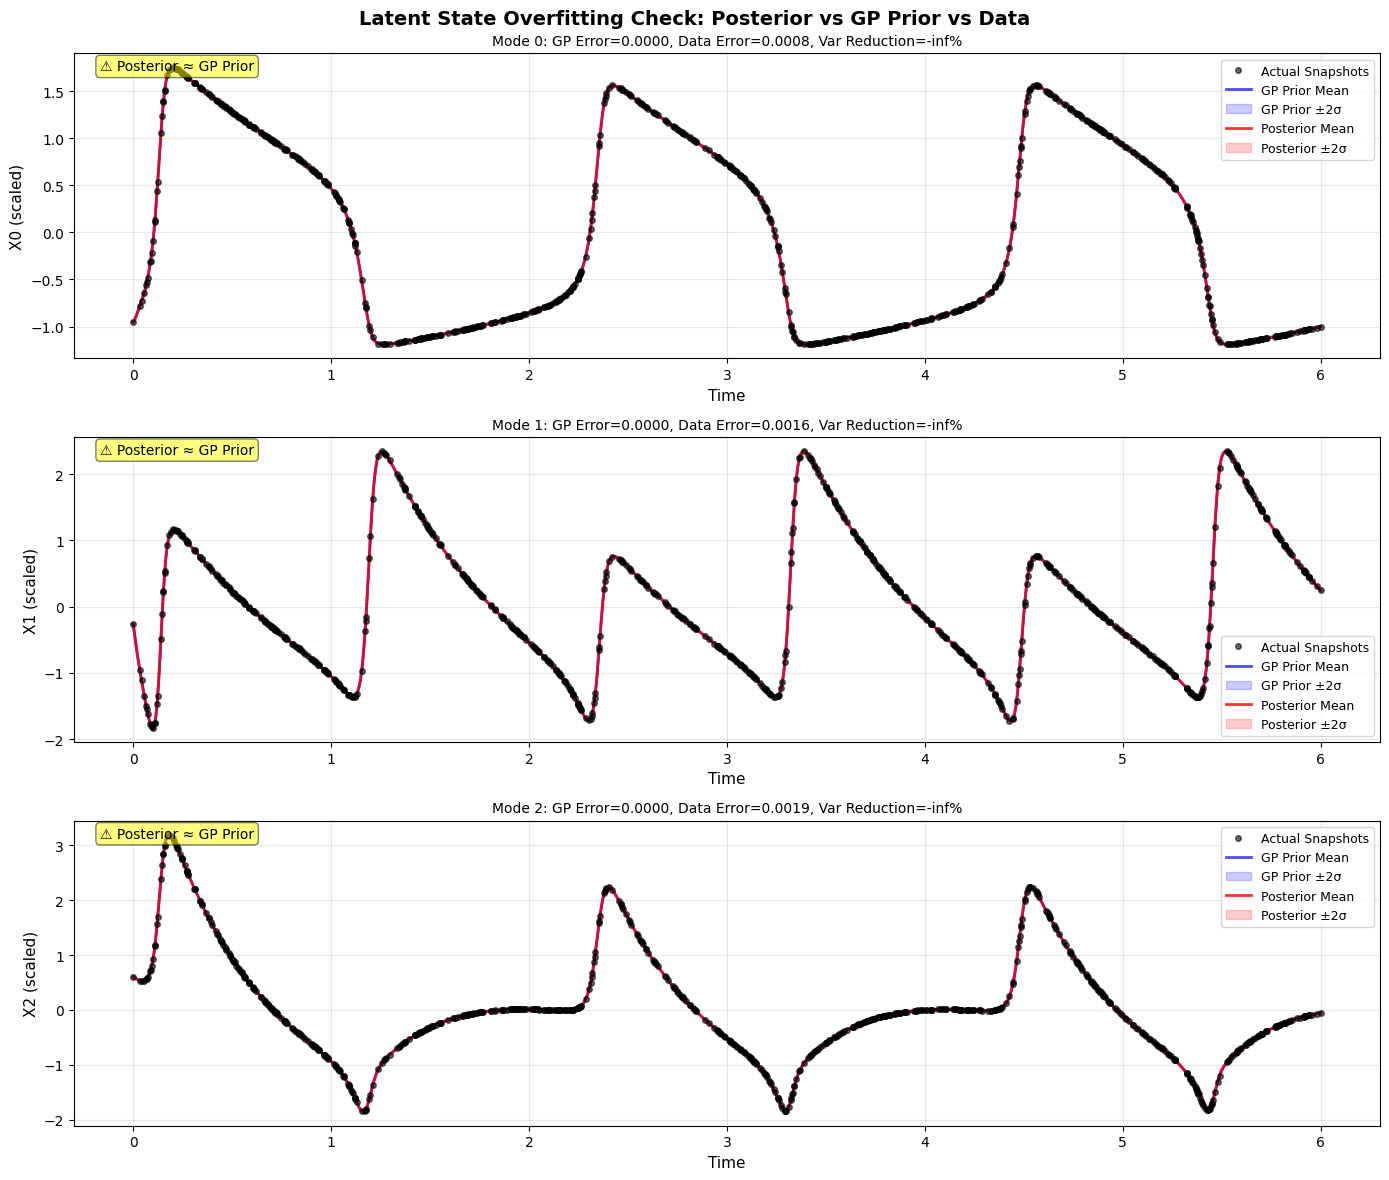


LATENT STATE FITTING SUMMARY

Mode 0:
  GP Prior Error:     0.000001
  Data Fit Error:     0.000792
  ⚠️  WARNING: Posterior is essentially identical to GP prior!
      → Model may be ignoring ODE constraints

Mode 1:
  GP Prior Error:     0.000001
  Data Fit Error:     0.001633
  ⚠️  WARNING: Posterior is essentially identical to GP prior!
      → Model may be ignoring ODE constraints

Mode 2:
  GP Prior Error:     0.000001
  Data Fit Error:     0.001909
  ⚠️  WARNING: Posterior is essentially identical to GP prior!
      → Model may be ignoring ODE constraints



In [44]:
# Plot latent states: Posterior vs GP Prior vs Actual Snapshots
print("Checking for latent state overfitting...\n")

# Compute statistics for posterior X samples
X_posterior_mean = Xs.mean(axis=0)  # Shape: (numPODmodes, num_time_steps)
X_posterior_std = Xs.std(axis=0)

# Data to compare against (in same space as posterior samples)
actual_snapshots = snapshots_compressed_scaled if USE_SCALED_DATA else snapshots_compressed

# Interpolate actual snapshots to eval points
from scipy.interpolate import interp1d
actual_snapshots_interp = np.zeros((numPODmodes, len(time_domain_eval_training)))
for i in range(numPODmodes):
    interp_func = interp1d(time_domain_sampled, actual_snapshots[i], 
                          kind='cubic', fill_value='extrapolate')
    actual_snapshots_interp[i] = interp_func(time_domain_eval_training)

# Create comparison plot
fig, axes = plt.subplots(numPODmodes, 1, figsize=(14, 4*numPODmodes))
if numPODmodes == 1:
    axes = [axes]

for i in range(numPODmodes):
    ax = axes[i]
    
    # Plot actual snapshots (truth)
    ax.plot(time_domain_sampled, actual_snapshots[i], 'ko', 
            markersize=4, label='Actual Snapshots', alpha=0.6, zorder=3)
    
    # Plot GP prior mean (from Xs_means)
    ax.plot(time_domain_eval_training, Xs_means[i], 'b-', 
            linewidth=2, label='GP Prior Mean', alpha=0.7)
    
    # Plot GP prior uncertainty (±2 std)
    gp_std = np.sqrt(np.diag(Xs_covs[i]))
    ax.fill_between(time_domain_eval_training, 
                     Xs_means[i] - 2*gp_std,
                     Xs_means[i] + 2*gp_std,
                     color='blue', alpha=0.2, label='GP Prior ±2σ')
    
    # Plot posterior mean from SVI
    ax.plot(time_domain_eval_training, X_posterior_mean[i], 'r-', 
            linewidth=2, label='Posterior Mean', alpha=0.8, zorder=2)
    
    # Plot posterior uncertainty
    ax.fill_between(time_domain_eval_training,
                     X_posterior_mean[i] - 2*X_posterior_std[i],
                     X_posterior_mean[i] + 2*X_posterior_std[i],
                     color='red', alpha=0.2, label='Posterior ±2σ')
    
    # Compute fit metrics
    # Error vs GP prior
    gp_error = np.linalg.norm(X_posterior_mean[i] - Xs_means[i]) / np.linalg.norm(Xs_means[i])
    
    # Error vs actual snapshots (at sampled points)
    actual_at_sampled = interp1d(time_domain_eval_training, X_posterior_mean[i], 
                                 kind='cubic', fill_value='extrapolate')(time_domain_sampled)
    data_error = np.linalg.norm(actual_at_sampled - actual_snapshots[i]) / np.linalg.norm(actual_snapshots[i])
    
    # Uncertainty reduction
    posterior_var = np.mean(X_posterior_std[i]**2)
    gp_var = np.mean(gp_std**2)
    var_reduction = (gp_var - posterior_var) / gp_var * 100
    
    ax.set_xlabel('Time', fontsize=11)
    ax.set_ylabel(f'X{i}' + (' (scaled)' if USE_SCALED_DATA else ''), fontsize=11)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title(
        f'Mode {i}: GP Error={gp_error:.4f}, Data Error={data_error:.4f}, Var Reduction={var_reduction:.1f}%',
        fontsize=10
    )
    
    # Diagnostic: Check if posterior is just copying GP prior (overfitting to prior)
    if gp_error < 0.01:
        ax.text(0.02, 0.98, '⚠️ Posterior ≈ GP Prior', 
                transform=ax.transAxes, fontsize=10, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
    
    # Check if posterior ignores data (large data error)
    if data_error > 0.5:
        ax.text(0.02, 0.88, '⚠️ Large Data Mismatch', 
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5))

fig.suptitle('Latent State Overfitting Check: Posterior vs GP Prior vs Data', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("LATENT STATE FITTING SUMMARY")
print("="*70)
for i in range(numPODmodes):
    actual_at_sampled = interp1d(time_domain_eval_training, X_posterior_mean[i], 
                                 kind='cubic', fill_value='extrapolate')(time_domain_sampled)
    gp_error = np.linalg.norm(X_posterior_mean[i] - Xs_means[i]) / np.linalg.norm(Xs_means[i])
    data_error = np.linalg.norm(actual_at_sampled - actual_snapshots[i]) / np.linalg.norm(actual_snapshots[i])
    
    print(f"\nMode {i}:")
    print(f"  GP Prior Error:     {gp_error:.6f}")
    print(f"  Data Fit Error:     {data_error:.6f}")
    
    if gp_error < 0.01:
        print(f"  ⚠️  WARNING: Posterior is essentially identical to GP prior!")
        print(f"      → Model may be ignoring ODE constraints")
    elif gp_error < 0.05:
        print(f"  → Posterior stays very close to GP prior")
    else:
        print(f"  ✓ Posterior deviates from GP prior (influenced by ODE constraints)")
    
    if data_error > 0.3:
        print(f"  ⚠️  WARNING: Large mismatch with actual data!")
        print(f"      → Check if scaling is correct or if model is failing")

print("\n" + "="*70)

## 10.1 Posterior Operator Derivative Matching

Compare posterior mean operator derivatives with GP predictions to validate improvement over prior.

Plotting posterior mean operator derivative matching...
Using posterior mean X (not interpolated snapshots) for evaluation


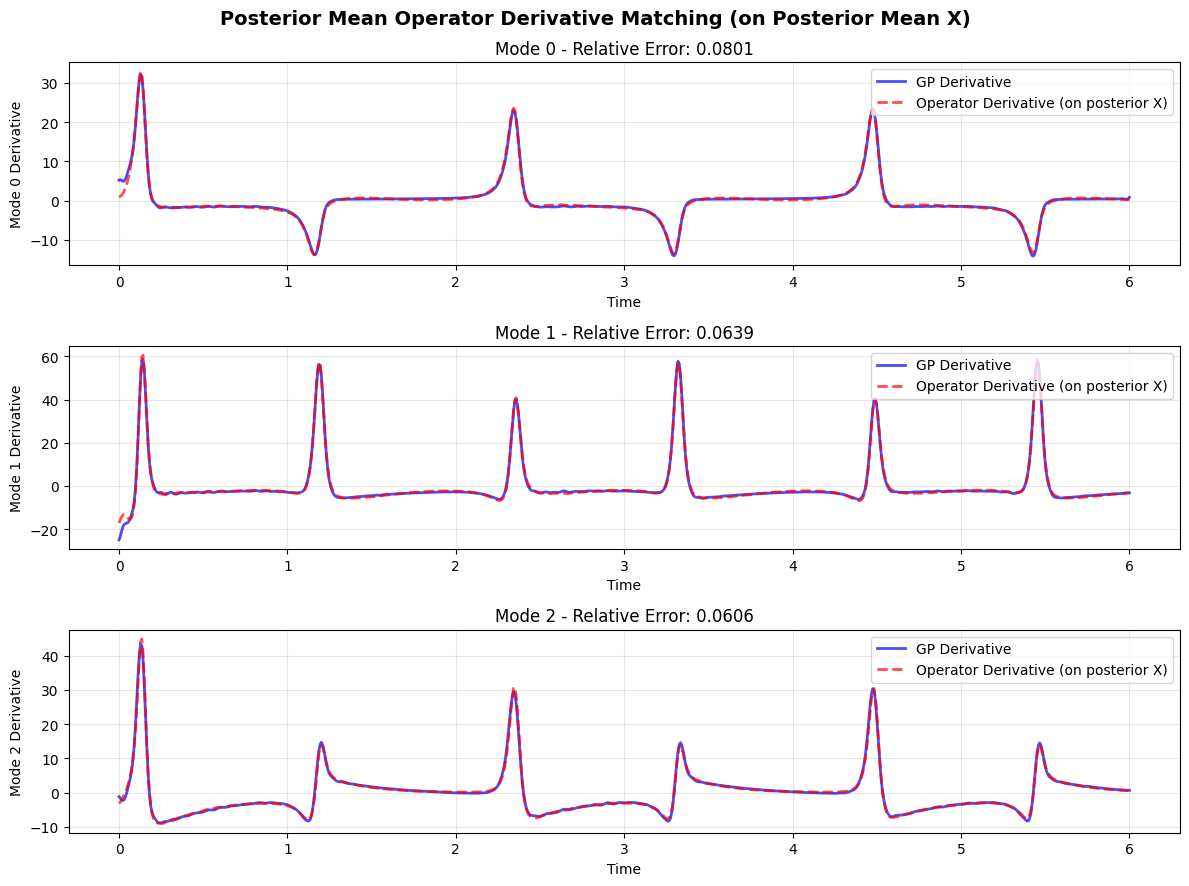

In [45]:
# Compute posterior mean latent states
X_posterior_mean_for_eval = np.array([final_samples[f'X{i}'].mean(axis=0) for i in range(numPODmodes)])

# CRITICAL: Evaluate operator on posterior mean X, not on interpolated snapshots!
# The operator was trained with sampled X values, so we must evaluate with posterior X
print("Plotting posterior mean operator derivative matching...")
print(f"Using posterior mean X (not interpolated snapshots) for evaluation")

# Compute operator derivatives using posterior mean X
if USE_SCALED_DATA:
    X_eval_orig = data_scaler.inverse_transform(X_posterior_mean_for_eval)
else:
    X_eval_orig = X_posterior_mean_for_eval

# Get operator derivatives
rom.model._extract_operators(np.array(O_mean))
f_X_operator = rom.model._assemble_data_matrix(X_eval_orig, inputs=inputs_eval_time) @ O_mean.T

if USE_SCALED_DATA:
    f_X_scaled = np.array([f_X_operator.T[i] / data_scaler.stds_[i, 0] for i in range(numPODmodes)])
else:
    f_X_scaled = f_X_operator.T

# Compute GP derivatives
mu_z_gp, _ = joint_gp_derivatives(Ls_means, Vs_means, time_domain_sampled, time_domain_eval_training, 
                                   use_scaled=USE_SCALED_DATA)

# Plot comparison
fig, axes = plt.subplots(numPODmodes, 1, figsize=(12, 3*numPODmodes))
if numPODmodes == 1:
    axes = [axes]

for i in range(numPODmodes):
    axes[i].plot(time_domain_eval_training, mu_z_gp[i], 'b-', linewidth=2, 
                label='GP Derivative', alpha=0.7)
    axes[i].plot(time_domain_eval_training, f_X_scaled[i], 'r--', linewidth=2, 
                label='Operator Derivative (on posterior X)', alpha=0.7)
    
    # Compute relative error
    diff = mu_z_gp[i] - f_X_scaled[i]
    rel_error = np.linalg.norm(diff) / (np.linalg.norm(mu_z_gp[i]) + 1e-10)
    
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel(f'Mode {i} Derivative')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_title(f'Mode {i} - Relative Error: {rel_error:.4f}')

fig.suptitle("Posterior Mean Operator Derivative Matching (on Posterior Mean X)", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Visualize Final Results

(1000, 3, 14) (1000, 3, 800)
Bad solve within training domain, skipping (3, 12)
Bad solve within training domain, skipping (3, 12)
Bad solve within training domain, skipping (3, 12)
Bad solve within training domain, skipping (3, 12)
Bad solve within training domain, skipping (3, 12)
Bad solve within training domain, skipping (3, 12)
Bad solve within training domain, skipping (3, 12)
Bad solve within training domain, skipping (3, 12)
Bad solve within training domain, skipping (3, 12)
Bad solve within training domain, skipping (3, 11)
Bad solve within training domain, skipping (3, 11)
Bad solve within training domain, skipping (3, 12)
Bad solve within training domain, skipping (3, 12)
Bad solve within training domain, skipping (3, 12)
Bad solve within training domain, skipping (3, 12)
Bad solve within training domain, skipping (3, 12)
Bad solve within training domain, skipping (3, 12)
Bad solve within training domain, skipping (3, 11)
Bad solve within training domain, skipping (3, 12)
Ba

IndexError: too many indices for array: array is 1-dimensional, but 3 were indexed

<Figure size 640x480 with 0 Axes>

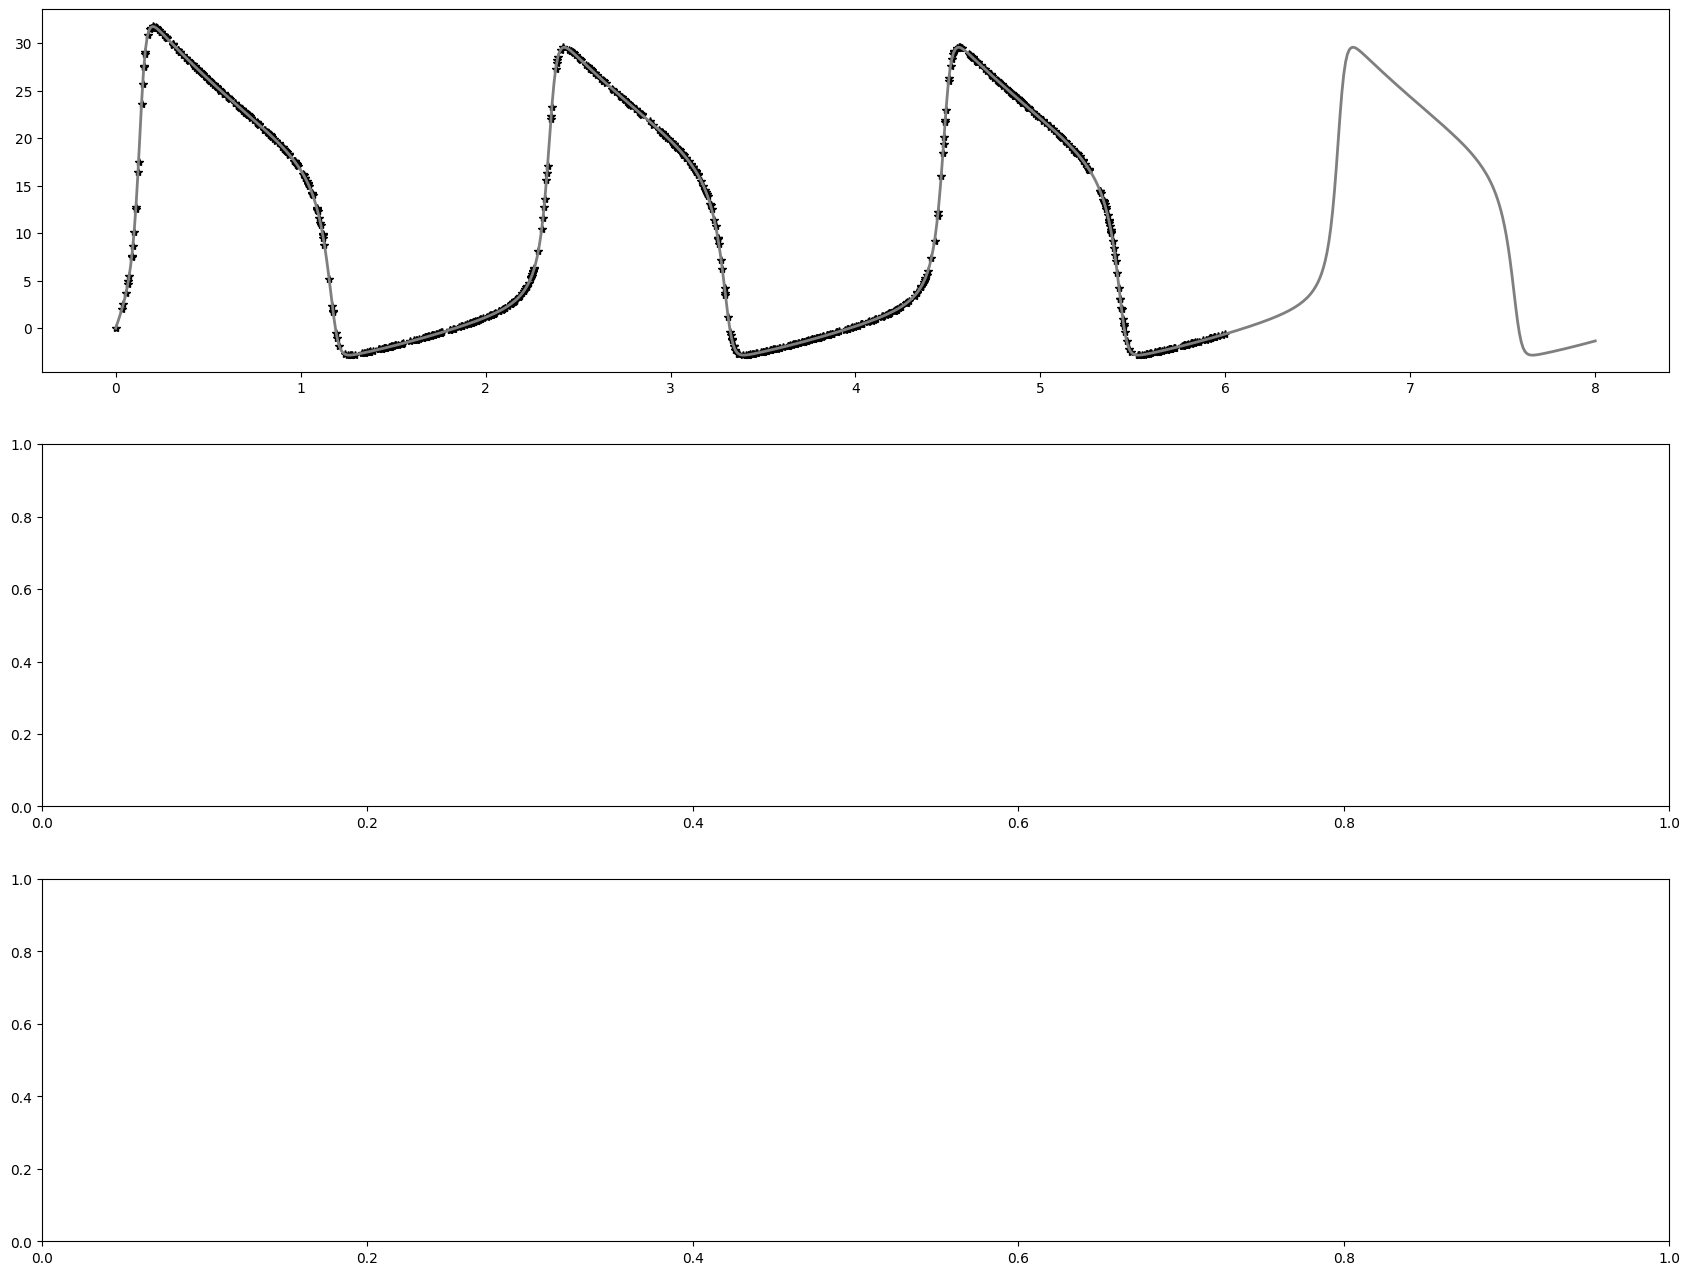

In [46]:
importlib.reload(fitz_plotter)

plotter.operator_plot(
    q0=Xs_means[:, 0], 
    operator_samples=final_samples['O'],
    latent_state_samples=[final_samples[f'X{i}'] for i in range(numPODmodes)],
    rom=rom,
    input_func=input_func,
    figsize=(21, 16),
    max_num_samples=num_pulls,
    plot_single=True
)